In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
from scipy import stats

def perform_welch(list_a, list_b):

    t_stat, p_value = stats.ttest_ind(list_a, list_b, equal_var=False)

    # Significance encoding
    if p_value < 0.001:
        stars = '***'
    elif p_value < 0.01:
        stars = '**'
    elif p_value < 0.05:
        stars = '*'
    else:
        stars = 'ns'

    print(f"Welch's t-test results")
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value:     {p_value:.4g}")
    print(f"significance:{stars}")


In [3]:
DATASET = 'fluo'

#### 1. AUC over LNK curve

In [4]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["TRA"].to_list()

    res = np.trapz(np.array(l))

    values_with_effect.append(res)

values_without_effect = []

for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["TRA"].to_list()

    res = np.trapz(np.array(l))

    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: 3.9716
p-value:     0.005354
significance:**


#### 2. Best LNK value

In [5]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["TRA"].to_list()

    res = max(l)

    values_with_effect.append(res)

values_without_effect = []

for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["TRA"].to_list()

    res = max(l)

    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: 6.2271
p-value:     2.214e-05
significance:***


#### 3. LNK value after first epoch

In [6]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["TRA"].to_list()

    res = l[0]

    values_with_effect.append(res)

values_without_effect = []
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["TRA"].to_list()

    res = l[0]
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: -0.3603
p-value:     0.724
significance:ns


#### 4. LNK value after last measured epoch

In [7]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["TRA"].to_list()

    res = l[-1]

    values_with_effect.append(res)

values_without_effect = []
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["TRA"].to_list()

    res = l[-1]
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: 4.0350
p-value:     0.00492
significance:**


#### 5. LNK value at maximum counterfactual and treatment

In [8]:
values_with_effect = []
indices = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["TRA"].to_list()

    res = max(l)
    indices.append(l.index(res))

    values_with_effect.append(res)

values_without_effect = []
indexloc = 0
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["TRA"].to_list()

    res = l[indices[indexloc]]
    indexloc += 1
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: 5.1269
p-value:     0.0009129
significance:***


In [9]:
values_with_effect = []
indices = []

for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["TRA"].to_list()

    res = max(l)
    indices.append(l.index(res))

    values_with_effect.append(res)

values_without_effect = []
indexloc = 0
for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["TRA"].to_list()

    res = l[indices[indexloc]]
    indexloc += 1
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: -1.2087
p-value:     0.2536
significance:ns


#### 6. Per-Epoch t-test

In [10]:
withs = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["TRA"].to_list()
    withs.append(l)

withouts = []
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["TRA"].to_list()
    withouts.append(l)


withs = np.array(withs)
withouts = np.array(withouts)


for idx in range(300):
    a = list(withs[:, idx])
    b = list(withouts[:, idx])

    t_stat, p_value = stats.ttest_ind(a, b, equal_var=False)

    print(idx, t_stat, p_value, sep='\t')

0	-0.36028254920133507	0.7240404657636164
1	3.171534933201049	0.006807184918475411
2	-0.30040301648307494	0.7703266315687206
3	2.068205424836567	0.05784043158072242
4	0.7640430289809114	0.4637058858115438
5	3.530418694855004	0.006678822224941498
6	0.5367212928448212	0.604910266421192
7	3.1007172016795312	0.012043548738140317
8	0.8577157912629524	0.4079266925114545
9	2.5581052856939337	0.03703184203099986
10	3.3193465759770815	0.01115555814069659
11	2.028514262864115	0.08182002319631154
12	2.1384616722654046	0.05060881202550112
13	1.350721762712115	0.19843701131962413
14	2.56625832448874	0.025335797843663004
15	2.6489163548513726	0.01979456491038329
16	1.9170563049990927	0.0934283059852346
17	1.6855894565923268	0.13550129384125156
18	2.0425545347551366	0.07488048122578035
19	2.711451369496322	0.02358105129913694
20	2.8610651956871225	0.013054313090613124
21	3.0769814675645444	0.008202636333259036
22	2.5746447842247115	0.03378889245421831
23	4.036308224329131	0.003459750806013944
24	3.42

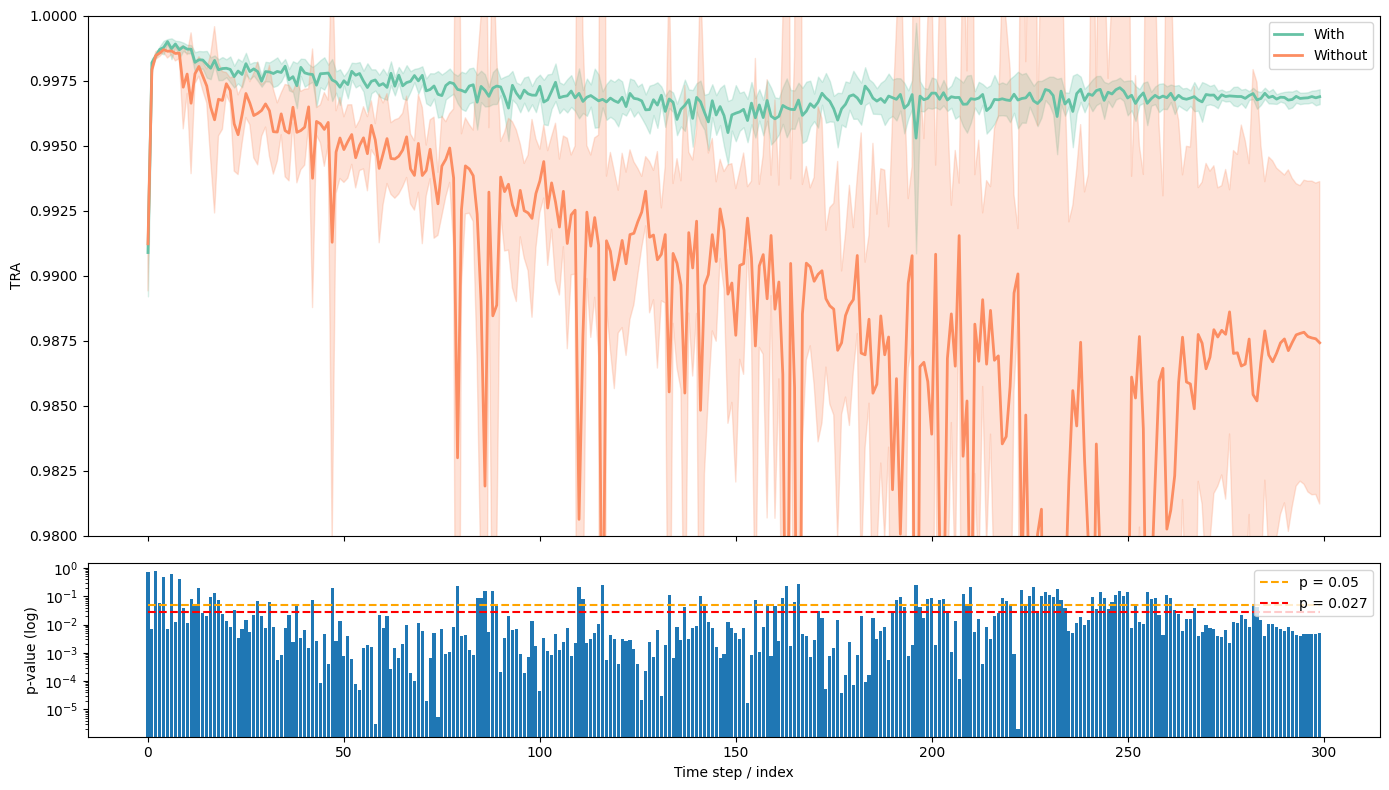

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

# -------------------------
# 1) Load your runs (WITH / WITHOUT)
# -------------------------
withs = []
for fname in sorted(os.listdir(f"effects/{DATASET}/with/")):
    df = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    withs.append(df["TRA"].to_numpy())

withouts = []
for fname in sorted(os.listdir(f"effects/{DATASET}/without/")):
    df = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    withouts.append(df["TRA"].to_numpy())

# Ensure all runs have the same length (truncate to min length if not)
minlen = min(min(map(len, withs)), min(map(len, withouts)))
withs = np.stack([x[:minlen] for x in withs], axis=0)       # shape: (n_runs, T)
withouts = np.stack([x[:minlen] for x in withouts], axis=0) # shape: (n_runs, T)

# -------------------------
# 2) Plot helper: mean ± std shading
# -------------------------
cmap = mpl.colormaps["Set2"]
ca, cb = cmap(0), cmap(1)

def plot_mean_shaded(ax, arr2d, color, label):
    """
    arr2d: shape (n_runs, T)
    """
    mean = arr2d.mean(axis=0)
    std  = arr2d.std(axis=0, ddof=0)
    x = np.arange(arr2d.shape[1])

    ax.plot(x, mean, color=color, label=label, linewidth=2)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.25)

# -------------------------
# 3) Compute per-index p-values (Welch by default; set equal_var=True for Student)
# -------------------------
pvals = np.empty(minlen, dtype=float)
tstats = np.empty(minlen, dtype=float)

for idx in range(minlen):
    w = withs[:, idx]
    wo = withouts[:, idx]
    res = stats.ttest_ind(w, wo, equal_var=False, nan_policy="omit")
    tstats[idx] = res.statistic
    pvals[idx]  = res.pvalue

x = np.arange(minlen)

# -------------------------
# 4) Build the combined figure (top: means; bottom: significance)
# -------------------------
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# --- TOP ---
plot_mean_shaded(ax_top, withs, ca, "With")
plot_mean_shaded(ax_top, withouts, cb, "Without")
ax_top.set_ylabel("TRA")  # or "Score" / your metric name
# Optional: uncomment if you want the same y-limits as your example
# ax_top.set_ylim(0.90, 1.0)
ax_top.legend(loc="best")

# --- BOTTOM ---
ax_bottom.bar(x, pvals)
ax_bottom.set_yscale("log")
ax_bottom.set_ylabel("p-value (log)")
ax_bottom.set_xlabel("Time step / index")

ymin = 0.98
ymax = 1.0

ax_top.set_ylim(ymin, ymax)

# threshold lines
ax_bottom.hlines(0.05, x.min(), x.max(), color="orange", linestyle="--", label="p = 0.05")
ax_bottom.hlines(0.027, x.min(), x.max(), color="red", linestyle="--", label="p = 0.027")
ax_bottom.legend(loc="upper right")

fig.tight_layout()
plt.savefig("with_without_plus_significance.pdf", bbox_inches="tight")
plt.show()
